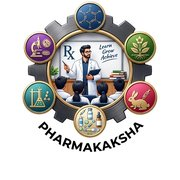

# BP101T · Unit V — Data Visualization with Matplotlib
**Pharmakaksha · Learn · Grow · Achieve**
*Basics of Python Programming for Pharmaceutical Sciences · B.Pharm Semester I · PCI NEP 2020*

This notebook contains every example and demo from the Unit V study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit5_Data_Visualization_with_Matplotlib.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit5_Data_Visualization_with_Matplotlib.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. Cells marked ⌨️ ask you to type something. Type your answer in the box that appears and press Enter.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All dosing and study data in this notebook are for learning Python only. They are not clinical tools.

## Practice datasets
The bar chart and box plot reuse the Unit IV datasets. Run the cell below once to create them.

In [ ]:
# Creates the practice dataset file(s) in the notebook folder

pk_study_text = """subject,formulation,weight_kg,cmax,tmax,auc
S01,Test,62,18.4,1.5,112.3
S02,Test,70,16.9,2.0,105.8
S03,Test,58,,1.5,120.1
S04,Test,81,15.2,2.5,98.6
S05,Reference,65,17.8,1.5,110.4
S06,Reference,74,15.9,2.0,101.2
S07,Reference,59,19.1,1.0,118.7
S08,Reference,77,16.3,2.0,
"""
with open("pk_study.csv", "w") as f:
    f.write(pk_study_text)

adr_reports_text = """report_id,drug,age,sex,reaction,serious
R001,Amoxicillin,34,F,Rash,No
R002,amoxicillin ,52,M,Diarrhoea,No
R003,Ibuprofen,67,M,GI bleeding,Yes
R004,Metformin,58,F,Nausea,No
R005,Ibuprofen,,F,Dyspepsia,No
R006,AMOXICILLIN,8,M,Urticaria,No
R007,Atorvastatin,61,M,Myalgia,No
R008,Ibuprofen,72,F,Renal impairment,Yes
R009,Metformin,49,M,Diarrhoea,No
R010,Amoxicillin,27,F,Anaphylaxis,Yes
"""
with open("adr_reports.csv", "w") as f:
    f.write(adr_reports_text)
print("Saved: pk_study.csv, adr_reports.csv")

## 5.1 Introduction to Matplotlib
We use Matplotlib's `pyplot` module, always imported as `plt`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# hides a harmless warning that savefig() shows on learn.pharmakaksha.com
import warnings, matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

**The basic recipe** is the same for every plot: figure → draw → axis labels **with units** → title → legend → save → show.

In [ ]:
x = [0, 1, 2, 4, 6, 8]                       # time, h
y = [0, 6.5, 8.0, 6.9, 5.0, 3.5]             # concentration, mg/L

plt.figure(figsize=(8, 5))              # 1. a new figure (width, height in inches)
plt.plot(x, y, label="Oral")            # 2. draw the data
plt.xlabel("Time (h)")                  # 3. label the x-axis WITH UNITS
plt.ylabel("Concentration (mg/L)")      #    label the y-axis WITH UNITS
plt.title("Concentration–time curve")   # 4. a title
plt.legend()                            # 5. a legend when there are 2+ series
plt.grid(alpha=0.3)                     # optional light grid
plt.savefig("plot.png", dpi=150)        # 6. save (before show)
plt.show()                              #    display

> **Exam point:** a plot without axis labels and units is incomplete, and loses marks.

## 5.2 Line plots: concentration–time curves (oral vs IV)
Both curves come from the one-compartment model:

$$C_{IV}(t) = \frac{Dose}{V} e^{-k_e t} \qquad C_{oral}(t) = \frac{F \cdot Dose \cdot k_a}{V (k_a - k_e)} \left(e^{-k_e t} - e^{-k_a t}\right)$$

In [ ]:
dose, V, ke, ka, F = 500, 40, 0.173, 1.2, 0.9   # mg, L, 1/h, 1/h, fraction
t = np.linspace(0, 24, 97)                         # 0–24 h

c_iv = dose / V * np.exp(-ke * t)
c_oral = F * dose * ka / (V * (ka - ke)) * (np.exp(-ke * t) - np.exp(-ka * t))

plt.figure(figsize=(8, 5))
plt.plot(t, c_iv, color="#12303A", linewidth=2.5, label="IV bolus")
plt.plot(t, c_oral, color="#E07A2E", linewidth=2.5, linestyle="--", label="Oral")
plt.xlabel("Time (h)")
plt.ylabel("Plasma concentration (mg/L)")
plt.title("Concentration–time curve: IV vs oral (500 mg)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Find Cmax with `max()` and Tmax with `argmax()`, the position of the largest value:

In [ ]:
print(f"Cmax = {c_oral.max():.2f} mg/L at Tmax = {t[c_oral.argmax()]} h")
print(f"IV C0 = {c_iv[0]} mg/L; half-life = {0.693 / ke:.1f} h")

**Interpretation:** IV starts at its highest level (C₀ = Dose/V = 12.5 mg/L) and falls exponentially. Oral rises to Cmax ≈ 8.1 mg/L at Tmax ≈ 2 h, then declines in parallel with IV, because kₑ is the same. The oral peak is lower because F = 0.9 and elimination starts during absorption.

**Semi-log plot.** On a log y-axis the IV decline becomes a **straight line**, with slope −kₑ/2.303.

In [ ]:
plt.figure(figsize=(8, 5))
plt.semilogy(t, c_iv, color="#12303A", linewidth=2.5)      # log-scale y-axis
plt.xlabel("Time (h)")
plt.ylabel("Plasma concentration (mg/L, log scale)")
plt.title("IV bolus on a semi-log plot")
plt.grid(alpha=0.3, which="both")
plt.show()

## 5.3 Bar charts: ADR reporting across drugs
A bar chart compares a quantity across **categories**. Clean the drug names (Unit IV), count, and plot.

In [ ]:
adr = pd.read_csv("adr_reports.csv")
adr["drug"] = adr["drug"].str.strip().str.title()
counts = adr["drug"].value_counts()
print(counts)

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color="#17725C")
plt.bar_label(bars)                              # write the number on each bar
plt.xlabel("Drug")
plt.ylabel("Number of ADR reports")
plt.title("ADR reports by drug")
plt.show()

**Interpretation:** Amoxicillin has the most reports (4), but a raw count is not a risk. Real **reporting rates** divide by use, e.g. reports per 100,000 prescriptions.

**Variation:** `plt.barh()` draws horizontal bars, which suit long drug names. Start bars at zero; a cut axis exaggerates differences.

In [ ]:
plt.figure(figsize=(8, 4))
plt.barh(counts.index, counts.values, color="#17725C")
plt.xlabel("Number of ADR reports")
plt.title("ADR reports by drug (horizontal)")
plt.gca().invert_yaxis()                         # largest at the top
plt.show()

## 5.4 Dissolution profiles: Test vs Reference
A line plot with **markers**: the markers are the sampling times, and the lines only connect them.

In [ ]:
time = [0, 5, 10, 15, 30, 45, 60]                 # min
test = [0, 28, 52, 71, 88, 94, 97]                # % released
ref  = [0, 24, 47, 68, 86, 93, 96]

plt.figure(figsize=(8, 5))
plt.plot(time, test, marker="o", color="#E07A2E", label="Test")
plt.plot(time, ref, marker="s", color="#12303A", label="Reference")
plt.axhline(85, color="grey", linestyle=":", label="85% (rapid dissolution)")
plt.xlabel("Time (min)")
plt.ylabel("Drug released (%)")
plt.ylim(0, 105)
plt.title("Dissolution profiles: Test vs Reference")
plt.legend()
plt.show()

Both products release more than 85% by 30 min. The **similarity factor f2** puts "similar" into a number; 50–100 means similar:

$$f_2 = 50 \cdot \log_{10}\left(\frac{100}{\sqrt{1 + \frac{1}{n}\sum_{t=1}^{n}(R_t - T_t)^2}}\right)$$

In [ ]:
d = np.array(test[1:]) - np.array(ref[1:])       # skip time 0
f2 = 50 * np.log10(100 / np.sqrt(1 + np.mean(d ** 2)))
print(round(f2, 1))

This is a teaching calculation. Regulatory f2 rules are covered in biopharmaceutics.

## 5.5 Histograms, scatter plots and box plots
### Histogram: the distribution of one variable
100 simulated tablet weights in a weight-variation check:

In [ ]:
rng = np.random.default_rng(7)
weights = rng.normal(500, 6, 100)          # 100 simulated tablet weights, mg

plt.hist(weights, bins=12, color="#17725C", edgecolor="white")
plt.axvline(475, color="#E07A2E", linestyle="--")
plt.axvline(525, color="#E07A2E", linestyle="--", label="±5% limits")
plt.xlabel("Tablet weight (mg)"); plt.ylabel("Number of tablets")
plt.title("Weight variation: 100 tablets"); plt.legend(); plt.show()

print(f"mean {weights.mean():.0f} mg, range {weights.min():.0f}–{weights.max():.0f} mg")

### Scatter plot: the relationship between two variables

In [ ]:
dose = [5, 10, 20, 40, 80]            # mg
response = [12, 22, 38, 55, 68]       # % of maximum effect
plt.scatter(dose, response, color="#E07A2E", s=80)
plt.xlabel("Dose (mg)"); plt.ylabel("Response (% of maximum effect)")
plt.title("Dose–response"); plt.show()

The response rises but flattens at higher doses (the Emax shape). On a log dose axis it becomes the familiar sigmoid:

In [ ]:
plt.scatter(dose, response, color="#E07A2E", s=80)
plt.xscale("log")
plt.xlabel("Dose (mg, log scale)"); plt.ylabel("Response (% of maximum effect)")
plt.title("Dose–response on a log dose axis"); plt.show()

### Box plot: comparing distributions between groups
The line is the median, the box is the interquartile range, and the whiskers show the spread.

In [ ]:
pk = pd.read_csv("pk_study.csv")
test_cmax = pk[pk["formulation"] == "Test"]["cmax"].dropna()
ref_cmax = pk[pk["formulation"] == "Reference"]["cmax"].dropna()
plt.boxplot([test_cmax, ref_cmax], tick_labels=["Test", "Reference"])   # labels= in Matplotlib < 3.9
plt.ylabel("Cmax (µg/mL)"); plt.title("Cmax by formulation"); plt.show()

print("Medians:", test_cmax.median(), ref_cmax.median())

The boxes overlap heavily and the medians are close, which agrees with the groupby means from Unit IV.

## 5.6 Scientific interpretation and choosing the right chart
| Question | Chart | Pharma example |
| --- | --- | --- |
| How does it change over time? | Line (`plot`) | Concentration–time curve |
| How do categories compare? | Bar (`bar`, `barh`) | ADR reports per drug |
| How is one variable distributed? | Histogram (`hist`) | Tablet weights |
| Are two variables related? | Scatter (`scatter`) | Dose vs response |
| How do groups' spreads compare? | Box (`boxplot`) | Cmax of Test vs Reference |

**Five steps to interpret a plot:** read the axes → describe the pattern → pick out key values → compare → conclude with caution.

**Misleading-graph demo.** The same ADR counts with a cut y-axis (left) and a y-axis that starts at zero (right):

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(counts.index, counts.values, color="#B8963C")
ax1.set_ylim(0.8, 4.2)
ax1.set_title("Cut axis: differences look huge")
ax2.bar(counts.index, counts.values, color="#17725C")
ax2.set_ylim(0, 4.2)
ax2.set_title("Axis from zero: honest")
for ax in (ax1, ax2):
    ax.set_ylabel("Number of ADR reports")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Quick check
Which chart would you use to compare the spread of Tmax between Test and Reference? Decide, then run the cell to check.

In [ ]:
plt.boxplot([pk[pk["formulation"] == "Test"]["tmax"], pk[pk["formulation"] == "Reference"]["tmax"]],
            tick_labels=["Test", "Reference"])
plt.ylabel("Tmax (h)"); plt.title("Tmax by formulation"); plt.show()

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Plot the ADR counts as a horizontal bar chart, sorted from highest to lowest, with the count written on each bar.

In [ ]:
# your code here

**2.** Change kₑ to 0.35 h⁻¹ and re-plot the oral curve with the original. What happens to Cmax, Tmax and the half-life?

In [ ]:
# your code here

**3.** Plot a 12-month stability study (assay % vs month) with a 90% specification line, and estimate when the product would fail.

In [ ]:
# your code here

**4.** Save any plot as a PNG at 300 dpi. (On learn.pharmakaksha.com, find it in the file list and use **Download**.)

In [ ]:
# your code here

---
## Solutions

In [ ]:
# 1
plt.figure(figsize=(8, 4))
bars = plt.barh(counts.index, counts.values, color="#17725C")
plt.bar_label(bars)
plt.gca().invert_yaxis()
plt.xlabel("Number of ADR reports"); plt.title("ADR reports by drug"); plt.show()

In [ ]:
# 2
ke2 = 0.35
dose_mg = 500        # 'dose' was reused for the dose-response list, so use a new name
c_oral2 = F * dose_mg * ka / (V * (ka - ke2)) * (np.exp(-ke2 * t) - np.exp(-ka * t))
plt.figure(figsize=(8, 5))
plt.plot(t, c_oral, label="ke = 0.173 /h")
plt.plot(t, c_oral2, linestyle="--", label="ke = 0.35 /h")
plt.xlabel("Time (h)"); plt.ylabel("Plasma concentration (mg/L)")
plt.title("Effect of faster elimination"); plt.legend(); plt.show()
print(f"Cmax {c_oral.max():.2f} -> {c_oral2.max():.2f} mg/L")
print(f"Tmax {t[c_oral.argmax()]} -> {t[c_oral2.argmax()]} h")
print(f"t½ {0.693 / 0.173:.1f} -> {0.693 / ke2:.1f} h")

In [ ]:
# 3
month = np.arange(0, 13)
assay = 101.0 - 1.0 * month                     # % of label claim, a steady loss
fail = month[assay < 90]
plt.figure(figsize=(8, 5))
plt.plot(month, assay, marker="o", color="#12303A", label="Assay")
plt.axhline(90, color="#E07A2E", linestyle="--", label="90% specification")
plt.xlabel("Time (months)"); plt.ylabel("Assay (% of label claim)")
plt.title("Stability study"); plt.legend(); plt.show()
print("First month below 90%:", fail[0] if len(fail) else "none within 12 months")
print(f"Line crosses 90% at about {(101.0 - 90) / 1.0:.1f} months")

In [ ]:
# 4
plt.plot(time, test, marker="o", label="Test")
plt.plot(time, ref, marker="s", label="Reference")
plt.xlabel("Time (min)"); plt.ylabel("Drug released (%)"); plt.legend()
plt.savefig("dissolution.png", dpi=300)
plt.show()
print("Saved dissolution.png")

---
**You have finished BP101T.** Next course: BP201T Biostatistics. Pharmakaksha · Learn · Grow · Achieve